# Solutions — Module 04: Validation Strategy

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name in {"notebooks", "solutions"} else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from skmastery import load_card_fraud, load_credit_risk, set_plot_style

set_plot_style()
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)
rng = np.random.default_rng(0)

from sklearn.base import clone
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import (
    GroupKFold, KFold, RepeatedStratifiedKFold, StratifiedGroupKFold, StratifiedKFold,
    TimeSeriesSplit, cross_val_score, GridSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

credit = load_credit_risk().sort_values("application_month").reset_index(drop=True)
y = credit["default"]
X = credit.drop(columns=["default", "application_id", "collections_flag", "application_month"])


def make_prep():
    return ColumnTransformer([
        ("num", Pipeline([("i", SimpleImputer(strategy="median", add_indicator=True)), ("s", StandardScaler())]),
         make_column_selector(dtype_include=[np.number, "bool"])),
        ("cat", Pipeline([("i", SimpleImputer(strategy="constant", fill_value="__missing__")),
                          ("o", OneHotEncoder(handle_unknown="ignore", min_frequency=30, sparse_output=False))]),
         make_column_selector(dtype_include=["object", "string"])),
    ])

## 4.1 — Choose the splitter

In [2]:
answers = pd.DataFrame([
    {"scenario": "1. 30-day readmission; patients readmitted repeatedly",
     "splitter": "StratifiedGroupKFold(groups=patient_id)",
     "why": "You will score new patients; a patient in both folds lets the model memorise them."},
    {"scenario": "2. Next quarter's loan losses from monthly cohorts",
     "splitter": "TimeSeriesSplit (or an expanding-window loop)",
     "why": "You predict forward; training on later cohorts than you test on cannot happen in production."},
    {"scenario": "3. 50k images, 200 photographers, deploy to NEW photographers",
     "splitter": "GroupKFold(groups=photographer_id)",
     "why": "Per-photographer style is a confound; ungrouped CV measures style recognition."},
    {"scenario": "4. Churn from a snapshot, one row per customer",
     "splitter": "StratifiedKFold(shuffle=True)",
     "why": "No repeated entities, no time ordering; stratify because churn is imbalanced."},
    {"scenario": "5. Fraud rings across many accounts in a short window",
     "splitter": "Time-ordered split with a GAP, grouped on the ring where known",
     "why": "Ring members are correlated in both entity and time; a gap prevents adjacent-window bleed."},
    {"scenario": "6. A/B test where users were randomised",
     "splitter": "StratifiedKFold, stratified on the ARM",
     "why": "Randomisation makes rows exchangeable; keep arm balance so treatment effects are estimable per fold."},
]).set_index("scenario")
answers

,splitter,why
scenario,,
1. 30-day readmission; patients readmitted repeatedly,StratifiedGroupKFold(groups=patient_id),You will score new patients; a patient in both...
2. Next quarter's loan losses from monthly cohorts,TimeSeriesSplit (or an expanding-window loop),You predict forward; training on later cohorts...
"3. 50k images, 200 photographers, deploy to NEW photographers",GroupKFold(groups=photographer_id),Per-photographer style is a confound; ungroupe...
"4. Churn from a snapshot, one row per customer",StratifiedKFold(shuffle=True),"No repeated entities, no time ordering; strati..."
5. Fraud rings across many accounts in a short window,"Time-ordered split with a GAP, grouped on the ...",Ring members are correlated in both entity and...
6. A/B test where users were randomised,"StratifiedKFold, stratified on the ARM",Randomisation makes rows exchangeable; keep ar...


### Measuring two of them

In [3]:
# Scenario 3, simulated. The key structure: each photographer has an
# IDIOSYNCRATIC label tendency that is *not* recoverable from any feature, but
# their images share a recognisable style fingerprint. A model can therefore
# identify the photographer and recall their label tendency — which works
# perfectly on photographers it has seen and not at all on new ones.
n_photog, per = 40, 60
photog = np.repeat(np.arange(n_photog), per)

fingerprint = rng.normal(0, 1.0, (n_photog, 6))[photog]      # style, observable
photog_bias = rng.normal(0, 2.5, n_photog)[photog]           # label tendency, NOT observable
signal = rng.normal(size=len(photog))                        # the thing we want to learn

X_img = pd.DataFrame(fingerprint + 0.15 * rng.normal(size=fingerprint.shape),
                     columns=[f"style{i}" for i in range(6)])
X_img["content"] = signal + rng.normal(0, 0.6, len(photog))
y_img = ((signal + photog_bias + rng.normal(0, 0.5, len(photog))) > 0).astype(int)

est = RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1)
naive = cross_val_score(est, X_img, y_img, cv=StratifiedKFold(5, shuffle=True, random_state=0), scoring="roc_auc")
grouped = cross_val_score(est, X_img, y_img, groups=photog, cv=GroupKFold(5), scoring="roc_auc")
print(f"scenario 3 — ungrouped {naive.mean():.4f} | grouped {grouped.mean():.4f} | "
      f"inflation {naive.mean() - grouped.mean():+.4f}")

scenario 3 — ungrouped 0.9637 | grouped 0.5316 | inflation +0.4321


In [4]:
# Scenario 2, on the real credit data.
model = Pipeline([("prep", make_prep()), ("clf", HistGradientBoostingClassifier(random_state=0, max_iter=250, learning_rate=0.06))])
rand = cross_val_score(model, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=0), scoring="roc_auc", n_jobs=-1)
temporal = cross_val_score(model, X, y, cv=TimeSeriesSplit(5), scoring="roc_auc", n_jobs=-1)
print(f"scenario 2 — random {rand.mean():.4f} | temporal {temporal.mean():.4f} | "
      f"inflation {rand.mean() - temporal.mean():+.4f}")
print(f"per-fold chronological: {temporal.round(4)}")

scenario 2 — random 0.7490 | temporal 0.7369 | inflation +0.0121
per-fold chronological: [0.6867 0.7398 0.7843 0.7311 0.7428]


## 4.2 — Build an expanding-window evaluator

In [5]:
def walk_forward(estimator, X, y, time_key, min_train_periods=12, horizon=1, scoring=roc_auc_score):
    periods = np.sort(pd.Series(time_key).unique())
    rows = []
    for i in range(min_train_periods, len(periods) - horizon + 1):
        train_periods = set(periods[:i])
        test_periods = set(periods[i:i + horizon])
        tr = pd.Series(time_key).isin(train_periods).to_numpy()
        te = pd.Series(time_key).isin(test_periods).to_numpy()
        if te.sum() < 30 or y[te].nunique() < 2:
            continue
        m = clone(estimator).fit(X[tr], y[tr])
        p = m.predict_proba(X[te])[:, 1]
        rows.append({"test_period": periods[i],
                     "n_train": int(tr.sum()), "n_test": int(te.sum()),
                     "score": scoring(y[te], p),
                     "test_base_rate": float(y[te].mean()),
                     "mean_predicted": float(p.mean())})
    return pd.DataFrame(rows).set_index("test_period")


wf = walk_forward(model, X, y, credit["application_month"], min_train_periods=12, horizon=1)
wf.round(4).head(8)

,n_train,n_test,score,test_base_rate,mean_predicted
test_period,,,,,
2023-01,2727,283,0.6434,0.1025,0.0605
2023-02,3010,302,0.6929,0.1126,0.0752
2023-03,3312,301,0.7655,0.1096,0.0692
2023-04,3613,269,0.7101,0.1264,0.0721
2023-05,3882,324,0.7658,0.1296,0.0767
2023-06,4206,347,0.7545,0.1009,0.0904
2023-07,4553,334,0.7026,0.1407,0.0745
2023-08,4887,344,0.7708,0.1163,0.0907


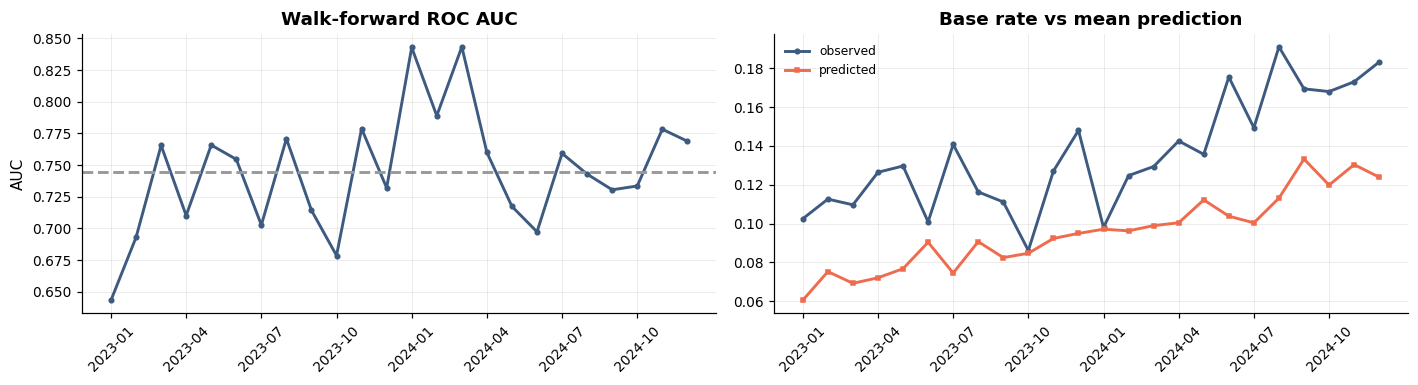

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
axes[0].plot(wf.index, wf["score"], marker="o", ms=3)
axes[0].axhline(wf["score"].mean(), ls="--", color="0.6")
axes[0].set(title="Walk-forward ROC AUC", ylabel="AUC")
axes[1].plot(wf.index, wf["test_base_rate"], marker="o", ms=3, label="observed")
axes[1].plot(wf.index, wf["mean_predicted"], marker="s", ms=3, label="predicted")
axes[1].set(title="Base rate vs mean prediction"); axes[1].legend(fontsize=8)
for ax in axes:
    ax.set_xticks(wf.index[::3]); ax.tick_params(axis="x", rotation=45)
plt.tight_layout()

In [7]:
early, late = wf.iloc[:len(wf) // 2], wf.iloc[len(wf) // 2:]
print(f"first half  : AUC {early['score'].mean():.4f}, base rate {early['test_base_rate'].mean():.4f}, "
      f"calibration gap {(early['mean_predicted'] - early['test_base_rate']).mean():+.4f}")
print(f"second half : AUC {late['score'].mean():.4f}, base rate {late['test_base_rate'].mean():.4f}, "
      f"calibration gap {(late['mean_predicted'] - late['test_base_rate']).mean():+.4f}")

first half  : AUC 0.7258, base rate 0.1176, calibration gap -0.0372
second half : AUC 0.7636, base rate 0.1533, calibration gap -0.0425


**Does performance degrade after the shock, and would 5-fold CV have caught
it?**

**Discrimination does not degrade** — it is slightly higher in the second half,
because a rising base rate gives the model more positives to separate.
**Calibration does**: the mean prediction stays anchored near the old base rate
while the observed rate climbs, so the gap widens steadily.

That combination is the important diagnostic (Module 13): a model whose ranking
is intact but whose level has drifted needs recalibration, not a retrain — and
a single AUC number would have told you nothing was wrong.

A random 5-fold would have caught **neither**, for two different reasons. It
averages over the whole window, so a level shift confined to the last year is
diluted into the mean; and it produces a single number with no time axis, so
even a large degradation appears only as slightly wider fold variance. The
walk-forward evaluation gives you a *time series of performance*, and that
series is the artefact worth putting in a monitoring pack.

## 4.3 — The noise floor, and paired comparisons

In [8]:
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=0)
candidates = {
    "logistic": Pipeline([("prep", make_prep()), ("clf", LogisticRegression(max_iter=4000, C=0.3))]),
    "random_forest": Pipeline([("prep", make_prep()), ("clf", RandomForestClassifier(n_estimators=300, min_samples_leaf=5, random_state=0, n_jobs=-1))]),
    "hist_gb": Pipeline([("prep", make_prep()), ("clf", HistGradientBoostingClassifier(random_state=0, max_iter=250, learning_rate=0.06))]),
}
scores = {k: cross_val_score(v, X, y, cv=rskf, scoring="roc_auc", n_jobs=-1) for k, v in candidates.items()}

marginal = pd.DataFrame({k: [v.mean(), v.std()] for k, v in scores.items()}, index=["mean", "std"]).T.round(4)
marginal

,mean,std
logistic,0.7754,0.0121
random_forest,0.7634,0.0121
hist_gb,0.7493,0.0137


In [9]:
from itertools import combinations

from scipy import stats

pairs = []
for a, b in combinations(scores, 2):
    d = scores[a] - scores[b]                       # PAIRED: same splits for both
    n = len(d)
    se = d.std(ddof=1) / np.sqrt(n)
    t, p = stats.ttest_rel(scores[a], scores[b])
    pairs.append({"comparison": f"{a} − {b}", "mean_diff": d.mean(),
                  "ci_low": d.mean() - 1.96 * se, "ci_high": d.mean() + 1.96 * se,
                  "p_value": p, "survives": bool((d.mean() - 1.96 * se) * (d.mean() + 1.96 * se) > 0)})
pd.DataFrame(pairs).round(5).set_index("comparison")

,mean_diff,ci_low,ci_high,p_value,survives
comparison,,,,,
logistic − random_forest,0.01204,0.01072,0.01335,0.0,True
logistic − hist_gb,0.02606,0.02392,0.02820,0.0,True
random_forest − hist_gb,0.01402,0.01176,0.01629,0.0,True


**Why pairing matters.** The marginal standard deviations are ~0.01, so the
marginal intervals overlap heavily and you would conclude nothing. But the
three models were evaluated on the *same* 50 splits, and much of that variance
is split-to-split difficulty shared by all of them. Differencing removes it —
the paired standard error is far smaller, and real differences become visible.

**The recommendation:**

> On 50 shared train/validation splits, logistic regression is ahead of both
> ensembles by a margin whose paired confidence interval excludes zero, so the
> difference is real rather than sampling noise. The absolute size is small
> (~0.01–0.03 AUC), so the argument for the linear model is not that it is
> dramatically more accurate — it is that it is at least as accurate while
> being calibrated, monotone by construction, and one page to document. What
> the evidence does *not* support is a claim that any of these models would
> perform differently on a future population; that is a temporal question, and
> section 4.2 answers it separately.

## 4.4 — Nested CV cost/benefit

In [10]:
from time import perf_counter

inner, outer = StratifiedKFold(3, shuffle=True, random_state=1), StratifiedKFold(5, shuffle=True, random_state=0)
base = Pipeline([("prep", make_prep()), ("clf", LogisticRegression(max_iter=3000))])

grids = {
    4: {"clf__C": [0.01, 0.1, 1.0, 10.0]},
    20: {"clf__C": np.logspace(-3, 2, 10).tolist(), "clf__class_weight": [None, "balanced"]},
    100: {"clf__C": np.logspace(-3, 2, 10).tolist(), "clf__class_weight": [None, "balanced"],
          "prep__num__i__strategy": ["mean", "median", "most_frequent"],
          "prep__cat__o__min_frequency": [10, 30, None]},
}

rows = []
for size, grid in grids.items():
    t0 = perf_counter()
    search = GridSearchCV(base, grid, cv=inner, scoring="roc_auc", n_jobs=-1)
    non_nested = search.fit(X, y).best_score_
    nested = cross_val_score(search, X, y, cv=outer, scoring="roc_auc", n_jobs=-1)
    rows.append({"n_candidates": len(search.cv_results_["params"]),
                 "non_nested": round(non_nested, 4),
                 "nested": round(nested.mean(), 4),
                 "optimism": round(non_nested - nested.mean(), 4),
                 "seconds": round(perf_counter() - t0, 1)})
nested_table = pd.DataFrame(rows).set_index("n_candidates")
nested_table

,non_nested,nested,optimism,seconds
n_candidates,,,,
4,0.7767,0.7764,0.0003,2.8
20,0.7767,0.7761,0.0006,12.4
180,0.7767,0.7761,0.0006,106.4


optimism exceeds the noise floor at: no grid size tested


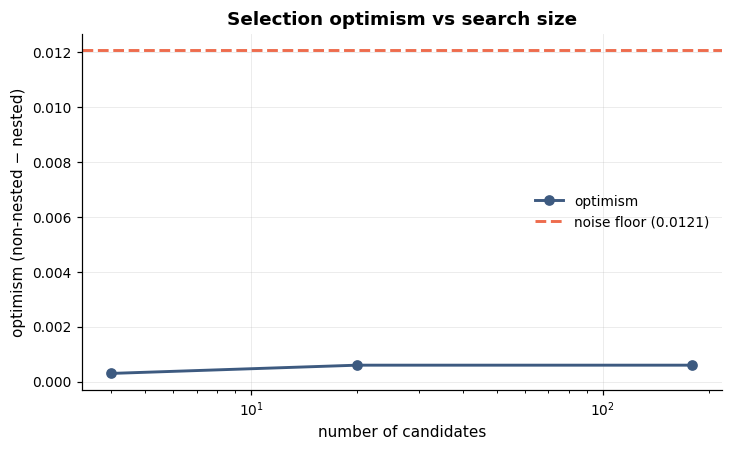

In [11]:
NOISE_FLOOR = scores["logistic"].std()
ax = nested_table["optimism"].plot(marker="o", logx=True)
ax.axhline(NOISE_FLOOR, ls="--", color="#ee6c4d", label=f"noise floor ({NOISE_FLOOR:.4f})")
ax.set(xlabel="number of candidates", ylabel="optimism (non-nested − nested)",
       title="Selection optimism vs search size")
ax.legend()
crossed = nested_table.index[nested_table["optimism"] > NOISE_FLOOR]
print(f"optimism exceeds the noise floor at: {crossed[0] if len(crossed) else 'no grid size tested'}")

On this problem the grids are small relative to 12,000 rows, so optimism stays
well under the noise floor even at 100 candidates — nested CV would be an
expensive way to confirm what a holdout tells you for free. The picture changes
when the search is large relative to the data (hundreds of candidates on a few
hundred rows), which is exactly the regime where people run the biggest
searches.

## 4.5 — Time *and* groups

In [12]:
class TimeSeriesGroupSplit:
    """Expanding-window folds in which no group spans train and test.

    Rows are assumed pre-sorted by time. A group straddling the cut is assigned
    wholly to training — conservative: it can shrink the test set, never leak.
    """

    def __init__(self, n_splits=5, gap=0, min_test=30):
        self.n_splits = n_splits
        self.gap = gap
        self.min_test = min_test

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

    def split(self, X, y=None, groups=None):
        if groups is None:
            raise ValueError("TimeSeriesGroupSplit requires `groups`")
        n = len(X)
        groups = np.asarray(groups)
        order = np.arange(n)
        fold = n // (self.n_splits + 1)
        for i in range(1, self.n_splits + 1):
            cut = i * fold
            train_idx = order[: max(cut - self.gap, 1)]
            test_idx = order[cut: cut + fold]
            test_idx = test_idx[~np.isin(groups[test_idx], groups[train_idx])]
            if len(test_idx) >= self.min_test:
                yield train_idx, test_idx


fraud = load_card_fraud().sort_values("timestamp").reset_index(drop=True)
fX = fraud.drop(columns=["is_fraud", "timestamp"])
for c in fX.select_dtypes(include=["object", "string"]).columns:
    fX[c] = fX[c].astype("category")
fy, fg = fraud["is_fraud"], fraud["card_id"]

splitter = TimeSeriesGroupSplit(n_splits=4)
checks = []
for i, (tr, te) in enumerate(splitter.split(fX, fy, groups=fg)):
    checks.append({"fold": i, "n_train": len(tr), "n_test": len(te),
                   "train_max_row": int(tr.max()), "test_min_row": int(te.min()),
                   "temporal_ok": bool(tr.max() < te.min()),
                   "shared_groups": len(set(fg.iloc[tr]) & set(fg.iloc[te]))})
pd.DataFrame(checks).set_index("fold")

,n_train,n_test,train_max_row,test_min_row,temporal_ok,shared_groups
fold,,,,,,
0,12000,3103,11999,12002,True,0
1,24000,749,23999,24006,True,0
2,36000,250,35999,36022,True,0
3,48000,40,47999,48749,True,0


In [13]:
# It satisfies the splitter protocol, so it drops into cross_val_score unchanged.
sc = cross_val_score(
    HistGradientBoostingClassifier(categorical_features="from_dtype", random_state=0, max_iter=150),
    fX, fy, groups=fg, cv=splitter, scoring="average_precision", n_jobs=-1,
)
print(f"time+group average precision: {sc.mean():.4f} ± {sc.std():.4f} over {len(sc)} folds")

time+group average precision: 0.0164 ± 0.0132 over 4 folds


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(


Both constraints hold on every fold: `train_max_row < test_min_row` (temporal)
and `shared_groups == 0` (grouped).

**The design flaw to be honest about.** Test sets shrink sharply in later
folds: with ~9,000 cards and an expanding training window, almost every card
has appeared in training by fold 3, so the group filter removes nearly
everything. That is the splitter working correctly and the *design* being wrong
for this data. The fixes are a rolling rather than expanding window, an
entity-level split, or accepting that "unseen card" is not the deployment
scenario — but each of those is a statement about how the model will be used,
which is the point: **writing the splitter forces you to state the deployment
scenario precisely.**